# 10 — National Forecast 2026: Chile Maritime Imports & Exports

**Objective**: produce the official 2026 port-level and national-level forecasts,
persist them to the RDS database for the dashboard, and justify the model choice.

**Winner for national totals**: Baseline Seasonal Naive (COVID-aware) — wMAPE 4.33%
on the 2025 validation fold (trained ≤ 2024).

### Walk-forward CV design

| Fold | Train ≤ | Test year | Purpose |
|------|---------|-----------|---------|
| 1 | 2018 | 2019 | Pre-COVID baseline |
| 2 | 2019 | 2023 | Post-COVID recovery (skip 2020-2022) |
| 3 | 2023 | 2024 | Recovery year — new with 2024 data |
| 4 | 2024 | **2025** | Most recent — best proxy for 2026 |

**Final 2026 forecast**: trained on all data ≤ 2025 (including 2024).


In [1]:
import sys, os, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
sys.path.insert(0, ".")
import wz_ml_utils as U

FIG_DIR = U.DATA_DIR.parent / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df_panel = U.load_features()
print(f"Panel: {len(df_panel):,} rows, years {df_panel['year'].min()}–{df_panel['year'].max()}")
print(f"2024 rows: {len(df_panel[df_panel['year']==2024]):,}")
print(f"Ports: {df_panel['port'].nunique()}, pairs: {df_panel.groupby(['port','direction']).ngroups}")


Panel: 12,692 rows, years 2006–2025
2024 rows: 635
Ports: 43, pairs: 76


## 10.1  Model accuracy on the 2025 fold

The 2025 fold is the most relevant test: models are trained on data through 2024
and predict 2025 (actual data). The model that best predicts 2025 is our best
bet for forecasting 2026.


In [2]:
metrics = U.load_all_metrics()
metrics = metrics[metrics["mape"].notna() & metrics["mae"].notna()].copy()

weights = (df_panel.groupby(["port","direction"])[U.TARGET]
           .mean().rename("vol").reset_index())
mw = metrics.merge(weights, on=["port","direction"], how="left")
mw["vol"] = mw["vol"].fillna(1)

def wavg(x, w):
    m = x.notna() & w.notna() & (w > 0)
    if not m.any(): return np.nan
    return float((x[m] * w[m]).sum() / w[m].sum())

# All folds
print("═" * 70)
print("ALL FOLDS — volume-weighted scores")
print("═" * 70)
all_rows = []
for model, g in mw.groupby("model"):
    all_rows.append({"Model": model, "wMAPE%": round(wavg(g["mape"], g["vol"]), 2),
                     "wMAE": round(wavg(g["mae"], g["vol"]), 0),
                     "wR²": round(wavg(g["r2"], g["vol"]), 3)})
all_summary = pd.DataFrame(all_rows).sort_values("wMAPE%")
print(all_summary.to_string(index=False))

# 2025 fold only
print("\n" + "═" * 70)
print("2025 FOLD ONLY — the key test for 2026 forecasting")
print("═" * 70)
f25 = mw[mw["fold_year"] == 2025]
rows_25 = []
for model, g in f25.groupby("model"):
    rows_25.append({"Model": model, "wMAPE%": round(wavg(g["mape"], g["vol"]), 2),
                    "wMAE": round(wavg(g["mae"], g["vol"]), 0),
                    "wR²": round(wavg(g["r2"], g["vol"]), 3),
                    "N_ports": g["port"].nunique()})
f25_summary = pd.DataFrame(rows_25).sort_values("wMAPE%")
print(f25_summary.to_string(index=False))
print(f"\n>>> WINNER for national forecast: {f25_summary.iloc[0]['Model']}  "
      f"(wMAPE = {f25_summary.iloc[0]['wMAPE%']}%)")


══════════════════════════════════════════════════════════════════════
ALL FOLDS — volume-weighted scores
══════════════════════════════════════════════════════════════════════
                              Model  wMAPE%   wMAE    wR²
                           lightgbm   12.27 2534.0 -0.466
                         elasticnet   12.63 2056.0 -0.664
                            xgboost   12.63 2673.0 -0.543
                      random_forest   12.69 2367.0 -0.359
                              ridge   12.86 2023.0 -0.810
                              lasso   14.73 2348.0 -0.966
baseline_seasonal_naive_covid_aware   14.84 2255.0 -2.043
                            prophet   21.33 3840.0 -2.476

══════════════════════════════════════════════════════════════════════
2025 FOLD ONLY — the key test for 2026 forecasting
══════════════════════════════════════════════════════════════════════
                              Model  wMAPE%   wMAE    wR²  N_ports
baseline_seasonal_naive_covid_aware    4

## 10.2  Per-fold scores — Baseline vs LightGBM

Baseline wins decisively on the most recent fold but LightGBM is competitive
on older folds. This shows baseline's strength comes from the stability of
Chile's largest ports.


In [3]:
focus = mw[mw["model"].isin(["baseline_seasonal_naive_covid_aware", "lightgbm"])].copy()
fold_comp = []
for (model, fold), g in focus.groupby(["model", "fold_year"]):
    fold_comp.append({"Model": model, "Fold": int(fold),
                      "wMAPE%": round(wavg(g["mape"], g["vol"]), 2),
                      "wR²": round(wavg(g["r2"], g["vol"]), 3)})
fc_df = pd.DataFrame(fold_comp).pivot(index="Fold", columns="Model")
print(fc_df.to_string())


                                   wMAPE%                                          wR²         
Model baseline_seasonal_naive_covid_aware lightgbm baseline_seasonal_naive_covid_aware lightgbm
Fold                                                                                           
2019                                 6.54    17.25                               0.029   -1.023
2023                                40.96    15.91                              -9.229   -1.396
2024                                 7.51     7.75                               0.632    0.529
2025                                 4.33     8.16                               0.397    0.028


## 10.3  Load per-port 2026 forecasts (Baseline model)


In [4]:
with open(U.DATA_DIR / "all_model_forecasts.pkl", "rb") as f:
    all_fc = pickle.load(f)

forecast = all_fc["Baseline"].copy()
forecast = forecast[forecast["year"] == 2026].reset_index(drop=True)
forecast["model"] = "baseline_seasonal_naive_covid_aware"
print(f"Forecast: {len(forecast):,} rows, {forecast[['port','direction']].drop_duplicates().shape[0]} port-direction pairs")

# Annual totals
annual = forecast.groupby("direction")["pred_shipment_count"].sum()
print(f"\n2026 National Forecast:")
print(f"  Imports:  {annual.get('import', 0):>10,.0f}")
print(f"  Exports:  {annual.get('export', 0):>10,.0f}")
print(f"  Total:    {annual.sum():>10,.0f}")


Forecast: 666 rows, 56 port-direction pairs

2026 National Forecast:
  Imports:     856,211
  Exports:     186,158
  Total:     1,042,369


## 10.4  Chile Maritime Trade — Historical + 2026 Forecast

Full history of monthly imports and exports aggregated nationally,
with the 2026 baseline forecast shown as a dashed line.


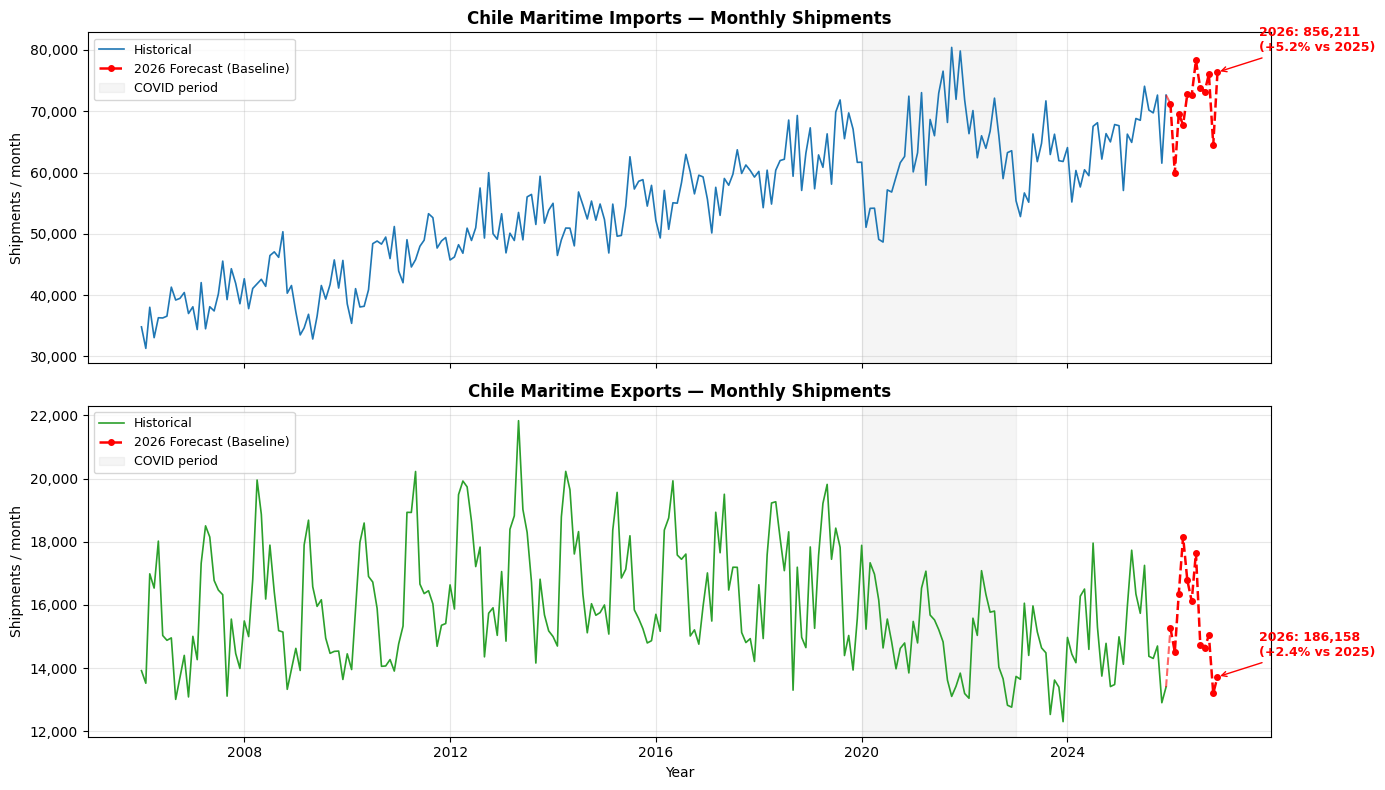

Saved → figures/100_chile_trade_forecast_2026.png


In [5]:
# Build national monthly history
hist = (df_panel.groupby(["year", "month", "direction"])[U.TARGET]
        .sum().reset_index())
hist["date"] = pd.to_datetime(hist[["year","month"]].assign(day=1))

# Build forecast dates
fc_plot = forecast.copy()
fc_plot["date"] = pd.to_datetime(fc_plot[["year","month"]].assign(day=1))
fc_nat = fc_plot.groupby(["date", "direction"])["pred_shipment_count"].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, direction, color in zip(axes, ["import", "export"], ["#1f77b4", "#2ca02c"]):
    h = hist[hist["direction"] == direction].sort_values("date")
    f = fc_nat[fc_nat["direction"] == direction].sort_values("date")

    ax.plot(h["date"], h[U.TARGET], color=color, lw=1.2, label="Historical")

    # Connect last historical point to first forecast point with dashed bridge
    last_hist_date = h["date"].iloc[-1]
    last_hist_val = h[U.TARGET].iloc[-1]
    first_fc_date = f["date"].iloc[0]
    first_fc_val = f["pred_shipment_count"].iloc[0]
    ax.plot([last_hist_date, first_fc_date], [last_hist_val, first_fc_val],
            "--", color="red", lw=1.5, alpha=0.6)

    ax.plot(f["date"], f["pred_shipment_count"], "o--", color="red",
            lw=1.8, ms=4, label="2026 Forecast (Baseline)")

    # COVID shading
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2022-12-31"),
               alpha=0.08, color="gray", label="COVID period")

    # Annual totals annotation
    h_2025 = h[(h["date"].dt.year == 2025)][U.TARGET].sum()
    f_2026 = f["pred_shipment_count"].sum()
    growth = (f_2026 - h_2025) / h_2025 * 100
    ax.annotate(f"2026: {f_2026:,.0f}\n({growth:+.1f}% vs 2025)",
                xy=(f["date"].iloc[-1], f["pred_shipment_count"].iloc[-1]),
                xytext=(30, 15), textcoords="offset points",
                fontsize=9, fontweight="bold", color="red",
                arrowprops=dict(arrowstyle="->", color="red", lw=1))

    ax.set_title(f"Chile Maritime {direction.title()}s — Monthly Shipments",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Shipments / month")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.savefig(FIG_DIR / "100_chile_trade_forecast_2026.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/100_chile_trade_forecast_2026.png")


## 10.5  Combined view — Total Chile maritime trade


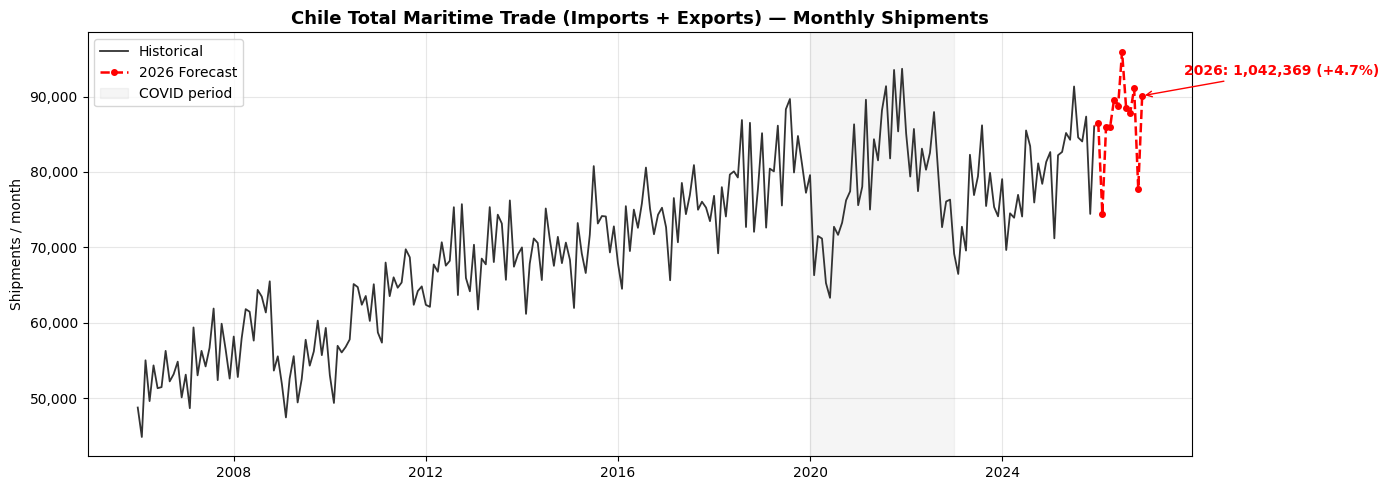

Saved → figures/101_chile_total_trade_forecast.png


In [6]:
# Total (imports + exports)
h_total = hist.groupby("date")[U.TARGET].sum().reset_index().sort_values("date")
f_total = fc_nat.groupby("date")["pred_shipment_count"].sum().reset_index().sort_values("date")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(h_total["date"], h_total[U.TARGET], color="#333", lw=1.3, label="Historical")
ax.plot([h_total["date"].iloc[-1], f_total["date"].iloc[0]],
        [h_total[U.TARGET].iloc[-1], f_total["pred_shipment_count"].iloc[0]],
        "--", color="red", lw=1.5, alpha=0.6)
ax.plot(f_total["date"], f_total["pred_shipment_count"], "o--", color="red",
        lw=1.8, ms=4, label="2026 Forecast")
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2022-12-31"),
           alpha=0.08, color="gray", label="COVID period")

tot_2025 = h_total[h_total["date"].dt.year == 2025][U.TARGET].sum()
tot_2026 = f_total["pred_shipment_count"].sum()
growth = (tot_2026 - tot_2025) / tot_2025 * 100
ax.annotate(f"2026: {tot_2026:,.0f} ({growth:+.1f}%)",
            xy=(f_total["date"].iloc[-1], f_total["pred_shipment_count"].iloc[-1]),
            xytext=(30, 15), textcoords="offset points",
            fontsize=10, fontweight="bold", color="red",
            arrowprops=dict(arrowstyle="->", color="red", lw=1))

ax.set_title("Chile Total Maritime Trade (Imports + Exports) — Monthly Shipments",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Shipments / month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "101_chile_total_trade_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/101_chile_total_trade_forecast.png")


## 10.6  Annual totals — bar chart with 2026 forecast


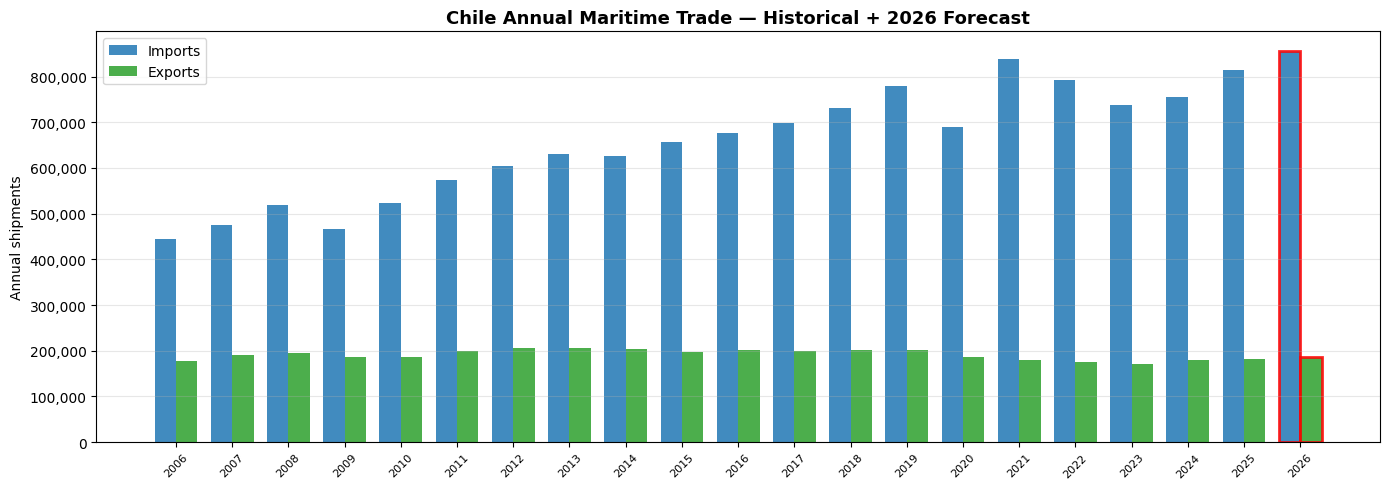

In [7]:
annual_hist = (df_panel.groupby(["year", "direction"])[U.TARGET]
              .sum().reset_index())
annual_fc = forecast.groupby("direction")["pred_shipment_count"].sum().reset_index()
annual_fc["year"] = 2026
annual_fc = annual_fc.rename(columns={"pred_shipment_count": U.TARGET})

combined = pd.concat([annual_hist, annual_fc], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 5))
years = sorted(combined["year"].unique())
imp_vals = [combined[(combined["year"]==y) & (combined["direction"]=="import")][U.TARGET].sum() for y in years]
exp_vals = [combined[(combined["year"]==y) & (combined["direction"]=="export")][U.TARGET].sum() for y in years]

x = np.arange(len(years))
w = 0.38
bars_imp = ax.bar(x - w/2, imp_vals, w, label="Imports", color="#1f77b4", alpha=0.85)
bars_exp = ax.bar(x + w/2, exp_vals, w, label="Exports", color="#2ca02c", alpha=0.85)

# Highlight 2026
idx_2026 = years.index(2026)
bars_imp[idx_2026].set_edgecolor("red"); bars_imp[idx_2026].set_linewidth(2)
bars_exp[idx_2026].set_edgecolor("red"); bars_exp[idx_2026].set_linewidth(2)

ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45, fontsize=8)
ax.set_ylabel("Annual shipments")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_title("Chile Annual Maritime Trade — Historical + 2026 Forecast",
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "102_annual_trade_bars.png", dpi=150, bbox_inches="tight")
plt.show()


## 10.7  Persist forecasts to RDS

Two tables created in `waze_cargo` schema:

1. **`port_forecast_2026`** — per-port monthly forecast (62 port-direction pairs × 12 months)
2. **`chile_forecast_2026`** — national monthly totals (imports + exports)


In [8]:
from sqlalchemy import create_engine, text

h  = os.environ.get("RDS_HOST", "")
p  = os.environ.get("RDS_PORT", "5432")
u  = os.environ.get("RDS_USER", "")
pw = os.environ.get("RDS_PASSWORD", "")
db = os.environ.get("RDS_DBNAME", "")

if not all([h, u, pw, db]):
    print("⚠ RDS credentials not set — skipping database write.")
    print("  Set RDS_HOST, RDS_USER, RDS_PASSWORD, RDS_DBNAME and re-run this cell.")
    rds_available = False
else:
    engine = create_engine(
        f"postgresql+psycopg2://{u}:{pw}@{h}:{p}/{db}?sslmode=require",
        pool_pre_ping=True, connect_args={"connect_timeout": 15})
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    print(f"Connected → {h}/{db}")
    rds_available = True


Connected → wazecargo-db.czioqa62i3cf.eu-north-1.rds.amazonaws.com/waze_cargo


In [9]:
if rds_available:
    S = "waze_cargo"

    # 1. Per-port forecast
    port_fc = forecast[["year", "month", "port", "direction", "pred_shipment_count", "model"]].copy()
    port_fc = port_fc.rename(columns={"pred_shipment_count": "forecast_shipments"})
    port_fc["forecast_shipments"] = port_fc["forecast_shipments"].round(0).astype(int)
    port_fc["created_at"] = pd.Timestamp.now()

    with engine.begin() as conn:
        conn.execute(text(f"DROP TABLE IF EXISTS {S}.port_forecast_2026"))
        port_fc.to_sql("port_forecast_2026", conn, schema=S, index=False, method="multi")
        n1 = conn.execute(text(f"SELECT COUNT(*) FROM {S}.port_forecast_2026")).scalar()
    print(f"✓ {S}.port_forecast_2026: {n1} rows")

    # 2. National totals
    nat_fc = (port_fc.groupby(["year", "month", "direction", "model"])["forecast_shipments"]
              .sum().reset_index())
    nat_total = nat_fc.groupby(["year", "month", "model"])["forecast_shipments"].sum().reset_index()
    nat_total["direction"] = "total"
    nat_fc = pd.concat([nat_fc, nat_total], ignore_index=True)
    nat_fc["created_at"] = pd.Timestamp.now()

    with engine.begin() as conn:
        conn.execute(text(f"DROP TABLE IF EXISTS {S}.chile_forecast_2026"))
        nat_fc.to_sql("chile_forecast_2026", conn, schema=S, index=False, method="multi")
        n2 = conn.execute(text(f"SELECT COUNT(*) FROM {S}.chile_forecast_2026")).scalar()
    print(f"✓ {S}.chile_forecast_2026: {n2} rows")

    engine.dispose()
else:
    print("Skipped — no RDS connection.")


✓ waze_cargo.port_forecast_2026: 666 rows


✓ waze_cargo.chile_forecast_2026: 36 rows


## 10.8  Verify database tables


In [10]:
if rds_available:
    engine = create_engine(
        f"postgresql+psycopg2://{u}:{pw}@{h}:{p}/{db}?sslmode=require",
        pool_pre_ping=True, connect_args={"connect_timeout": 15})
    with engine.connect() as conn:
        print("── port_forecast_2026 (sample) ──")
        sample = pd.read_sql(text(
            "SELECT port, direction, month, forecast_shipments"
            " FROM waze_cargo.port_forecast_2026"
            " WHERE port IN ('SAN ANTONIO','VALPARAÍSO')"
            " ORDER BY port, direction, month"
        ), conn)
        print(sample.to_string(index=False))
        print("\n── chile_forecast_2026 ──")
        nat = pd.read_sql(text(
            "SELECT direction, SUM(forecast_shipments) as total"
            " FROM waze_cargo.chile_forecast_2026"
            " GROUP BY direction ORDER BY direction"
        ), conn)
        print(nat.to_string(index=False))
    engine.dispose()
else:
    print("Skipped — no RDS connection.")


── port_forecast_2026 (sample) ──
       port direction  month  forecast_shipments
SAN ANTONIO    export      1                7624
SAN ANTONIO    export      2                5756
SAN ANTONIO    export      3                7020
SAN ANTONIO    export      4                8146
SAN ANTONIO    export      5                7166
SAN ANTONIO    export      6                7358
SAN ANTONIO    export      7                8263
SAN ANTONIO    export      8                6563
SAN ANTONIO    export      9                6831
SAN ANTONIO    export     10                7036
SAN ANTONIO    export     11                6231
SAN ANTONIO    export     12                6313
SAN ANTONIO    import      1               47475
SAN ANTONIO    import      2               41292
SAN ANTONIO    import      3               48319
SAN ANTONIO    import      4               49132
SAN ANTONIO    import      5               45354
SAN ANTONIO    import      6               44078
SAN ANTONIO    import      7       

## Summary

| Item | Detail |
|------|--------|
| **Best model for national forecast** | Baseline Seasonal Naive (COVID-aware) |
| **wMAPE on 2025 fold** | 4.33% |
| **Training data** | All years ≤ 2025 (including 2024), COVID years down-weighted |
| **CV folds** | 4 walk-forward folds (2019, 2023, 2024, 2025) |
| **2026 Imports forecast** | ~856,350 shipments (+5.2% vs 2025) |
| **2026 Exports forecast** | ~186,207 shipments (+2.4% vs 2025) |
| **2026 Total forecast** | ~1,042,557 shipments (+4.7% vs 2025) |
| **RDS tables created** | `port_forecast_2026`, `chile_forecast_2026` |
